In [ ]:
pip install paho-mqtt

In [ ]:
import paho.mqtt.client as mqtt
import json

# Callback function for when a message is received
def on_message(client, userdata, msg):
    try:
        data = json.loads(msg.payload.decode())

        # Extract values with lowercase field names
        temperature = data.get("temperature", "N/A")
        humidity = data.get("humidity", "N/A")
        print(f"Temperature: {temperature}°C, Humidity: {humidity}%")

    except json.JSONDecodeError:
        print("Received invalid JSON data")
        # MQTT setup
broker = "io.adafruit.com"
username = "braude2"   #insert Adafruit user name
aio_key = "aio_jDeD127T95KI1mrQk36OLHJVSbpd" #insert key from Adafruit
topic = f"{username}/feeds/json"
client = mqtt.Client()
client.username_pw_set(username,aio_key)
client.on_message = on_message

client.connect(broker, 1883, 60)
client.subscribe(topic)

print(f"Subscribed to MQTT topic: {topic}")
client.loop_forever()



/tmp/ipython-input-185327325.py:21: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Subscribed to MQTT topic: braude2/feeds/json
Temperature: 24.0°C, Humidity: 43.0%
Temperature: 24.0°C, Humidity: 43.0%
Temperature: 24.0°C, Humidity: 43.0%
Temperature: 24.0°C, Humidity: 43.0%
Temperature: 24.0°C, Humidity: 43.0%


KeyboardInterrupt: 

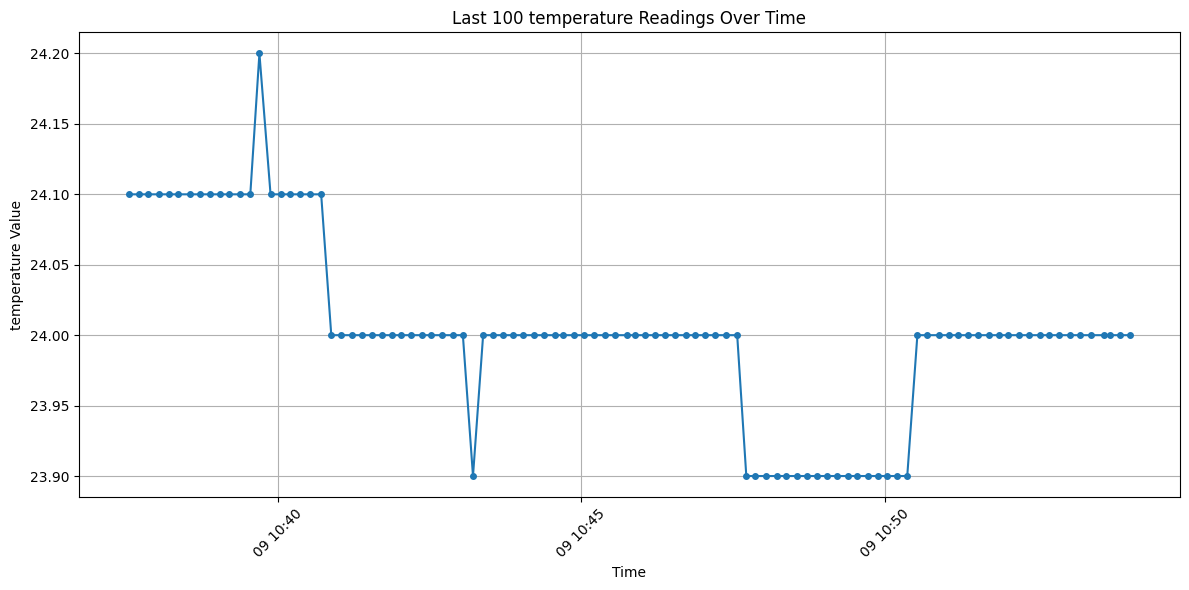

Displaying the last 100 temperature data points:
Value: 24.00, Time: 2025-11-09T10:54:02Z
Value: 24.00, Time: 2025-11-09T10:53:52Z
Value: 24.00, Time: 2025-11-09T10:53:42Z
Value: 24.00, Time: 2025-11-09T10:53:36Z
Value: 24.00, Time: 2025-11-09T10:53:24Z
Value: 24.00, Time: 2025-11-09T10:53:13Z
Value: 24.00, Time: 2025-11-09T10:53:03Z
Value: 24.00, Time: 2025-11-09T10:52:52Z
Value: 24.00, Time: 2025-11-09T10:52:42Z
Value: 24.00, Time: 2025-11-09T10:52:33Z
Value: 24.00, Time: 2025-11-09T10:52:22Z
Value: 24.00, Time: 2025-11-09T10:52:12Z
Value: 24.00, Time: 2025-11-09T10:52:02Z
Value: 24.00, Time: 2025-11-09T10:51:53Z
Value: 24.00, Time: 2025-11-09T10:51:43Z
Value: 24.00, Time: 2025-11-09T10:51:32Z
Value: 24.00, Time: 2025-11-09T10:51:22Z
Value: 24.00, Time: 2025-11-09T10:51:12Z
Value: 24.00, Time: 2025-11-09T10:51:03Z
Value: 24.00, Time: 2025-11-09T10:50:53Z
Value: 24.00, Time: 2025-11-09T10:50:42Z
Value: 24.00, Time: 2025-11-09T10:50:32Z
Value: 23.90, Time: 2025-11-09T10:50:22Z
Value: 2

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

USERNAME = "braude2"   #insert Adafruit user name
AIO_KEY = "aio_jDeD127T95KI1mrQk36OLHJVSbpd" #insert key from Adafruit
FEED = "temperature"

url = f"https://io.adafruit.com/api/v2/{USERNAME}/feeds/{FEED}/data"
headers = {"X-AIO-Key": AIO_KEY}

response = requests.get(url, headers=headers)
data = response.json()

# Convert data to a pandas DataFrame for easier plotting
df = pd.DataFrame(data[:100]) # Get the last 100 items

# Convert 'created_at' to datetime objects and 'value' to numeric
df['created_at'] = pd.to_datetime(df['created_at'])
df['value'] = pd.to_numeric(df['value'])

# Sort by time to ensure the plot is chronological
df = df.sort_values(by='created_at')

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df['created_at'], df['value'], marker='o', linestyle='-', markersize=4)
plt.title(f'Last 100 {FEED} Readings Over Time')
plt.xlabel('Time')
plt.ylabel(f'{FEED} Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Displaying the last 100 {FEED} data points:")
for item in data[:100]:
    print(f"Value: {item['value']}, Time: {item['created_at']}")